# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

- **Domain**: Agriculture
- **Project Theme**: Seasonal Agriculture Performance
- **Tools**: Python, Pandas, NumPy, Matplotlib, Seaborn

## Project Goal

Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships, and differences in the available data.

## 1. Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques, and communicate findings based on evidence from the data.

## 2. Project Objectives
- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate, and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.

## 3. Dataset
The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit, and resource usage.

**Dataset file:** `/content/seasonal_agriculture_performance_dataset (7).csv`

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [ ]:
#load dataset
file_path = '/content/seasonal_agriculture_performance_dataset (7).csv'
df = pd.read_csv(file_path)
print("data set load succesfully ")


data set load succesfully 


## 4.Inital data understanding

In [ ]:
#datashape
print ("Number of Rows:",df.shape[0])
print ("Number of Columns:",df.shape[1])


Number of Rows: 4000
Number of Columns: 28


In [ ]:
#top 5 rows
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
#bottom 5 rows
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [ ]:
#random sample records
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [ ]:
#columns names
print(df.columns.to_list())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
#datatypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
#nummerical summary statistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [ ]:
#categorical summary
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


5.Data Quality Analysis

In [ ]:
#missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage =(df.isnull().mean()*100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
  "Missing_count":missing,
  "missing_percentage":missing_percentage.round(2)
})
missing_summary [missing_summary["Missing_count"]>0]

,Missing_count,missing_percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


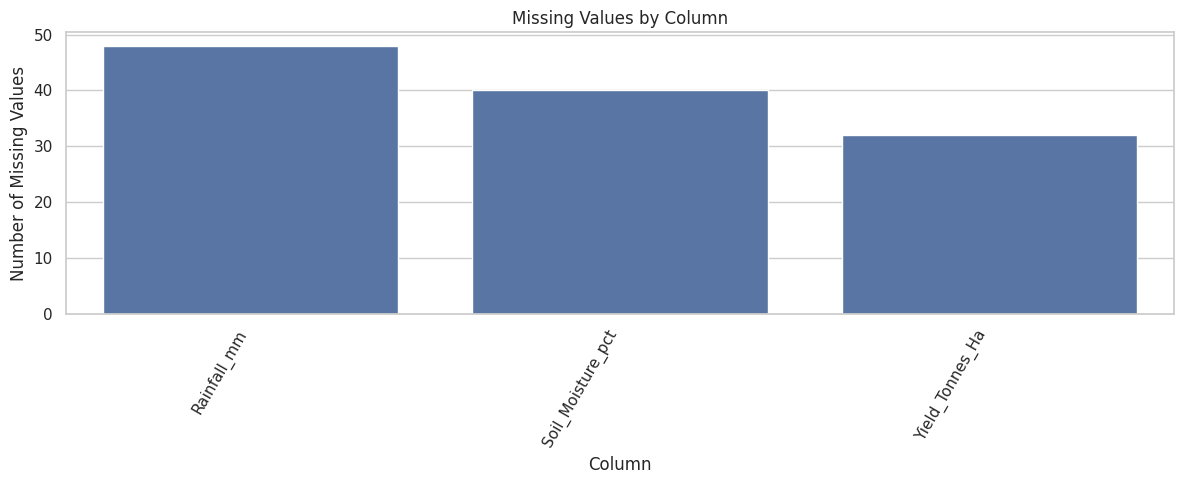

In [ ]:
#vizualize the missing values
plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
        print("No missing values found.")

In [ ]:
#duplicate recordss
duplicate_counts = df.duplicated().sum()
print("Number of Rows :",duplicate_counts)

Number of Rows : 0


In [ ]:
#remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing Duplicates",df.shape)

Shape after removing Duplicates (4000, 28)


In [ ]:
#check the datatypes again
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:

#check unique values for categorical columns
categorical_columns = df.select_dtypes(include="object").columns
for col in categorical_columns:
  print(f"\n{col}:")
  print(df[col].nunique(),"unique values")
  print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [ ]:
#check missing values after duplicate removal
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


# Missing value Treatment
Choose an appropriate strategy based on the nature of each variable.
Possible approaches:
• Remove records only when justified.
• Fill numerical values using an appropriate statistic when appropriate.
• Fill categorical values using a suitable category or method.
• Clearly document why the chosen approach is reasonable.
Do not blindly replace every missing value with zero.

In [ ]:
#Example zero imputation for numerical columns
#Students should review missingness before deciding wheather to use this approch
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
  if df[col].isnull().sum()>0:
    df[col] = df [col].fillna(df[col].median())
print ("Remaining missing values:",df.isnull().sum().sum())

Remaining missing values: 0


# Types of variables
• Identifier variables
• Categorical variables
• Numerical variables
• Environmental variables
• Operational variables
• Production/performance variables
• Economic variables
Student task: Explain which variables are most relevant to the seasonal-performance problem and why.

In [ ]:
#numerical columns and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)
#


Numerical Columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


# 7.Statistical Analysis
perform descriptive analysis to understand the distrubution and varition of the data
Students should interpret the statistics rather than displaying them  

In [ ]:
#Descriptive Statistics
stats = df [numeric_columns].describe().T
stats["range"] = stats ["max"]-stats["min"]
stats ["IQR"] = stats ["75%"]-stats["25%"]
stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [ ]:
#median and standard devition
satistical_summary = pd.DataFrame({
    "Mean":df[numeric_columns].mean(),
    "median":df[numeric_columns].median(),
    "std_dev":df[numeric_columns].std(),
    "Min":df[numeric_columns].min(),
    "Max":df[numeric_columns].max()
})
satistical_summary

,Mean,median,std_dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [ ]:
#Seasonal descriptive summary
season_summary = df.groupby("Season")[numeric_columns].agg(["mean","median","std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

# 8.Univriate Analysis


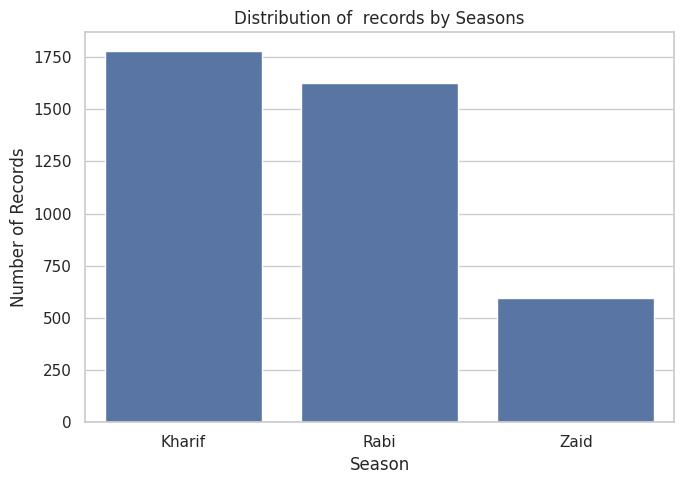

In [ ]:
#univriate : season distribution
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="Season")
plt.title("Distribution of  records by Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

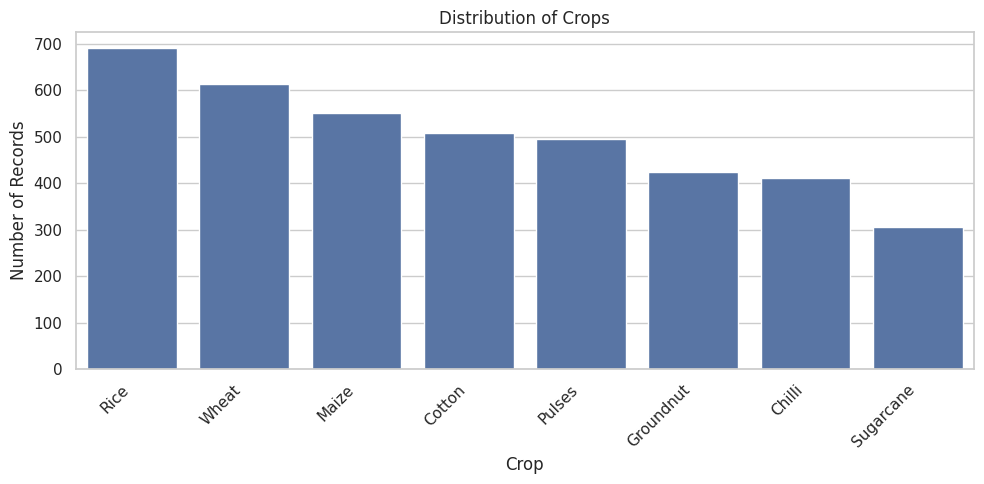

In [ ]:
#univriate crop distrubution
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="Crop",order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

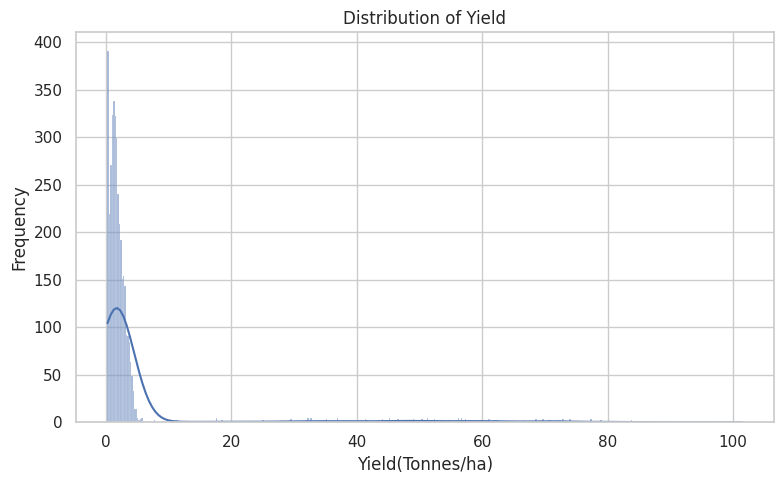

In [ ]:
#univariate Yeild distrubution
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Yield_Tonnes_Ha",kde=True)
plt.title("Distribution of Yield")
plt.xlabel("Yield(Tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

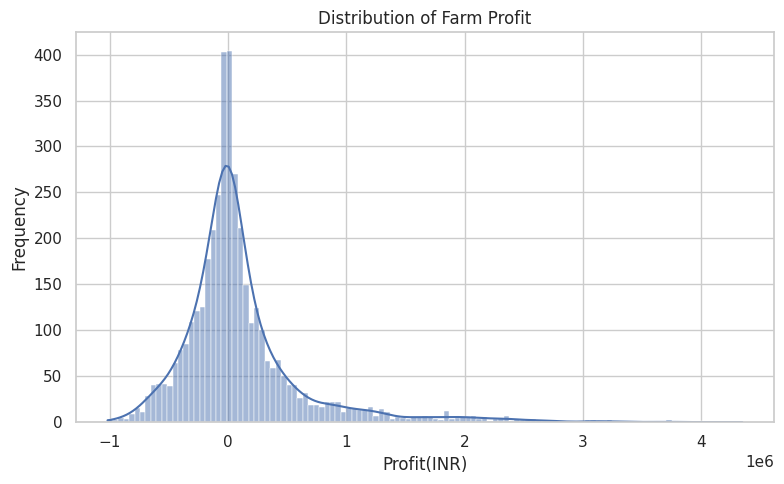

In [ ]:
#Univirate:profit distrbution
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Profit_INR",kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit(INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

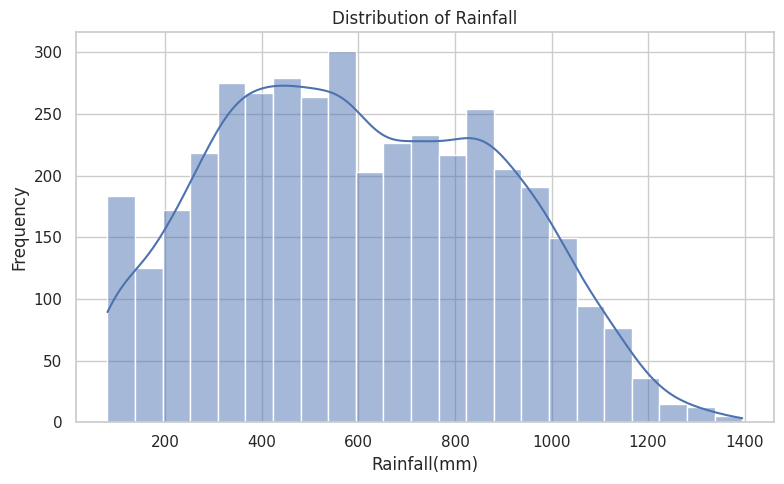

In [ ]:
#univriate :rainfall distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Rainfall_mm",kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall(mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

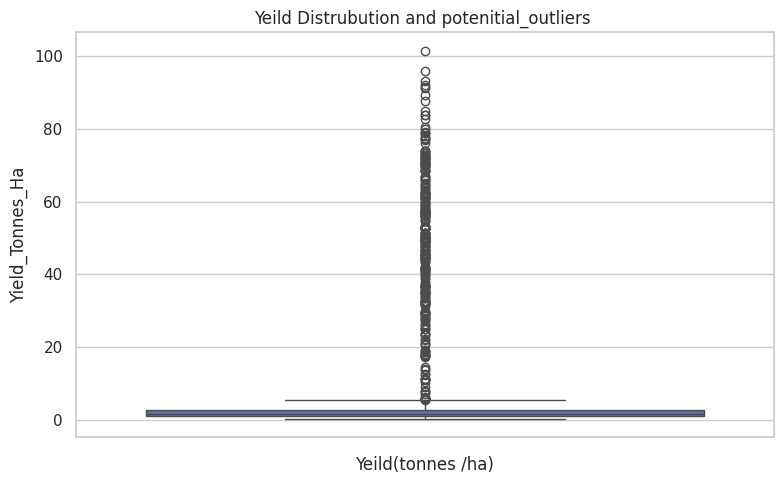

In [ ]:
#Univriate:Boxplot for yeild
plt.figure(figsize=(8,5))
sns.boxplot(data=df,y="Yield_Tonnes_Ha")
plt.title("Yeild Distrubution and potenitial_outliers ")
plt.xlabel("Yeild(tonnes /ha)")
plt.tight_layout()
plt.show()

# 9.Outlier Analysis
Investigate potential outliers using statistical and visual methods.
• A data-entry problem,
• A legitimate observation,
• Or something requiring further investigation.

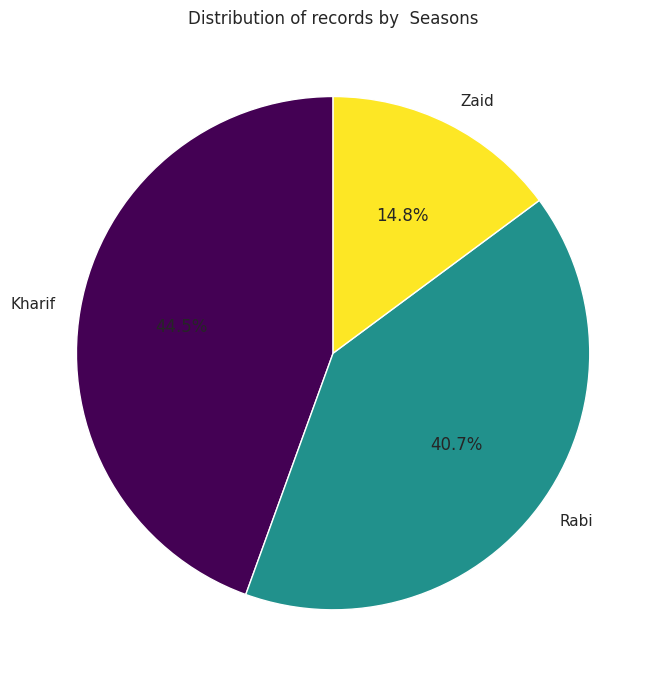

In [ ]:
#univriate: seasoned distribution (pie chart )
plt.figure(figsize=(7,7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%',startangle=90,cmap='viridis')
plt.title("Distribution of records by  Seasons")
plt.ylabel("")#hide the default 'seasons'label on the y- axis
plt.tight_layout()
plt.show()

In [ ]:
#IQR- based outlier summary for nummerical columns
outlier_summary_list = []
for col in numeric_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3-Q1
  lower_bound = Q1-1.5*IQR
  upper_bound = Q3+1.5*IQR
  outliers = ((df[col]<lower_bound) | (df[col]>upper_bound)).sum()

  outlier_summary_list.append({
      "columns":col,
      "lower_bound":lower_bound,
      "upper_bound":upper_bound,
      "outliers_count":outliers ,
      "outlier_Percentage":round (outliers/len(df)*100,2)
  })
outlier_summary = pd.DataFrame(outlier_summary_list).sort_values("outliers_count",ascending=False)
display(outlier_summary)

,columns,lower_bound,upper_bound,outliers_count,outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


# 10.Bivraite Analysis
Bivariate analysis examines relationships or differences between two variables.

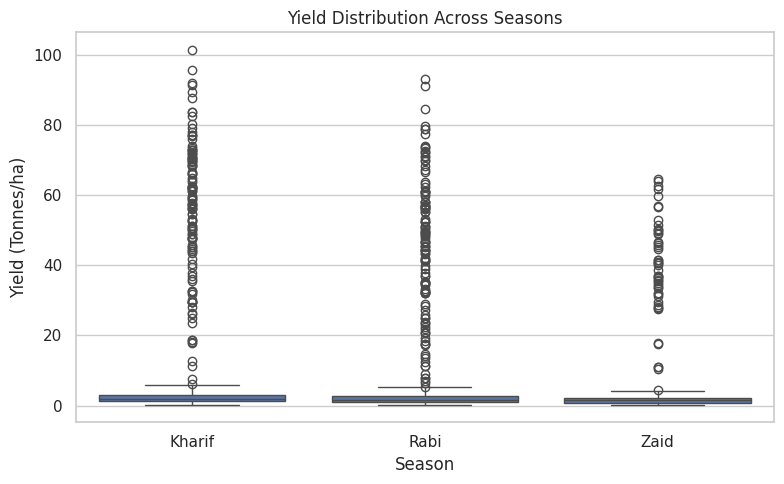

In [ ]:
#Bivraite Analysis :season vs yeild
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/ha)")
plt.tight_layout()
plt.show()

Bar Plots for Bivraite Analysis

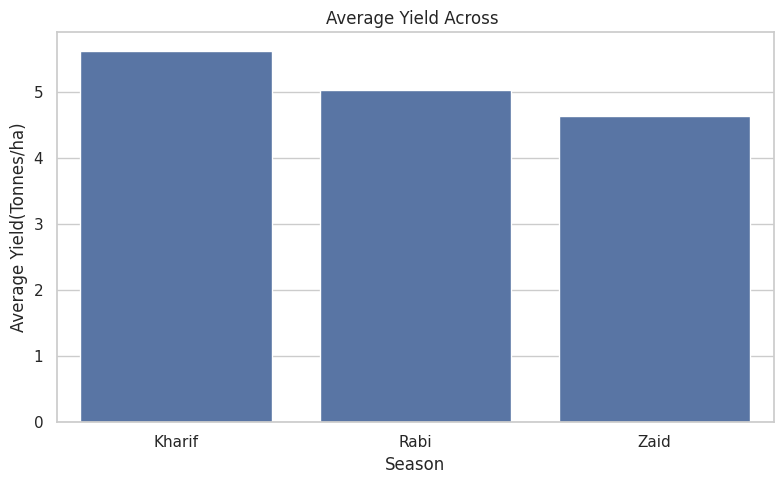

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Yield_Tonnes_Ha",errorbar=None)
plt.title("Average Yield Across ")
plt.xlabel("Season")
plt.ylabel("Average Yield(Tonnes/ha)")
plt.tight_layout()
plt.show()

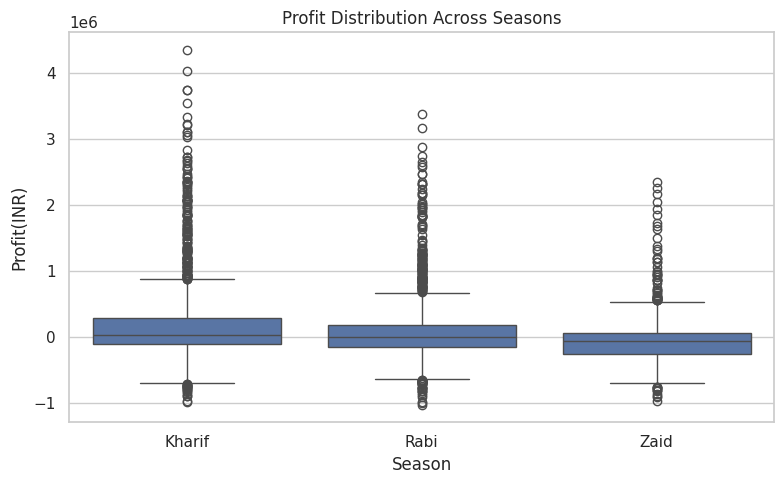

In [ ]:
#bivirate:Season vs profit
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit(INR)")
plt.tight_layout()
plt.show()

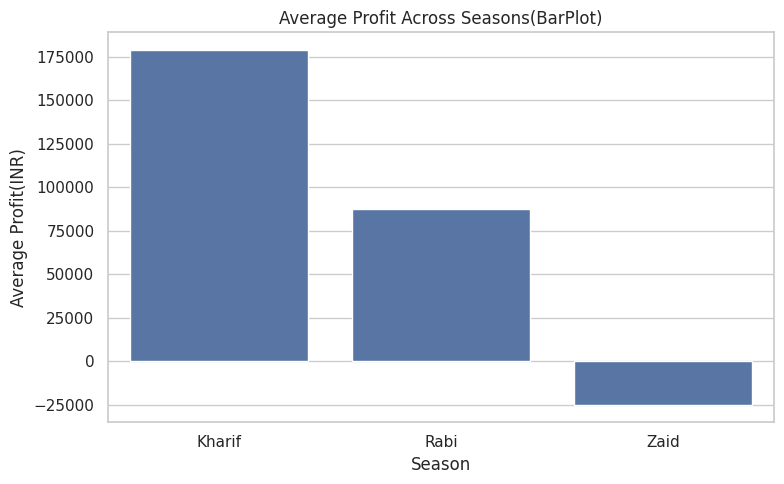

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Profit_INR",errorbar=None)
plt.title("Average Profit Across Seasons(BarPlot)")
plt.xlabel("Season")
plt.ylabel("Average Profit(INR)")
plt.tight_layout()
plt.show()

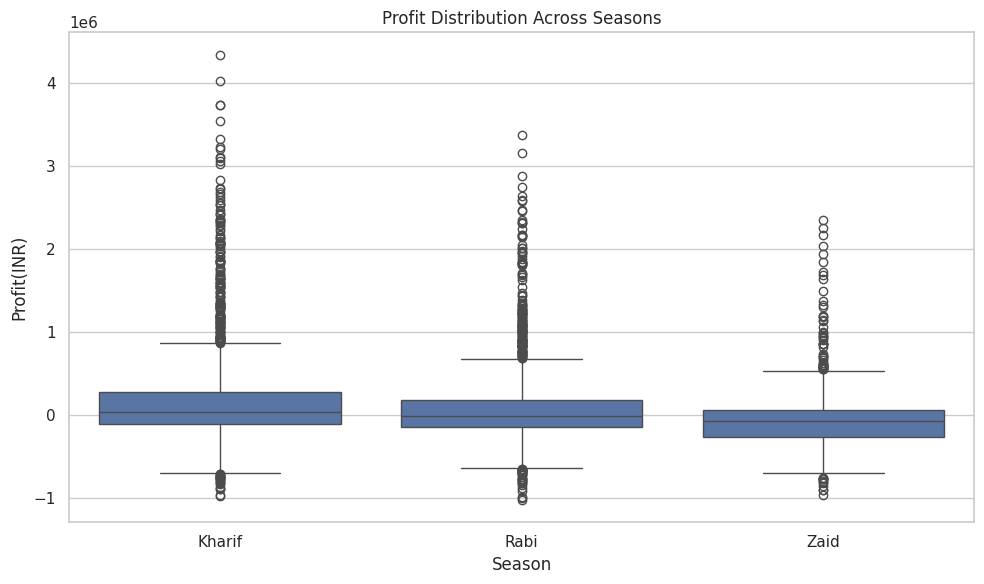

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="Season",y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit(INR)")
plt.tight_layout()
plt.show()

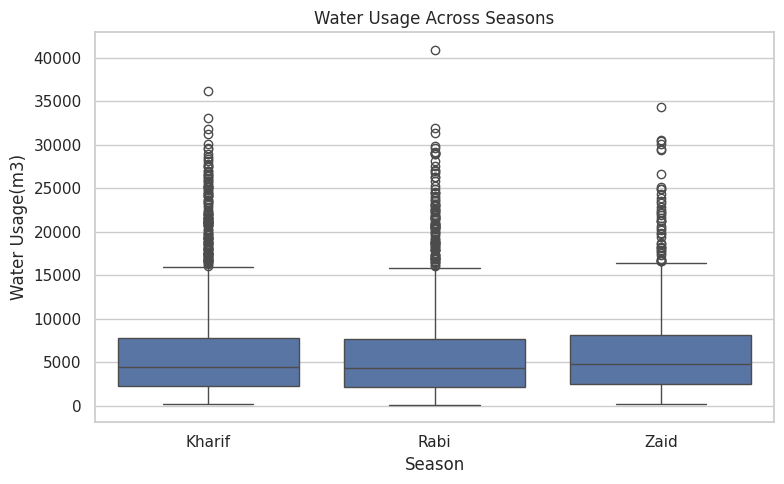

In [ ]:
#Bivariate:Seasons vs waterusage
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Usage(m3)")
plt.tight_layout()
plt.show()

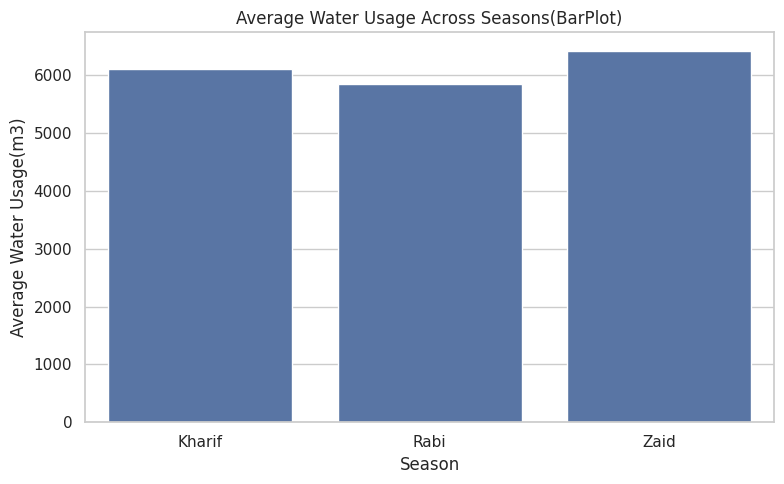

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Water_Used_m3",errorbar=None)
plt.title("Average Water Usage Across Seasons(BarPlot)")
plt.xlabel("Season")
plt.ylabel("Average Water Usage(m3)")
plt.tight_layout()
plt.show()

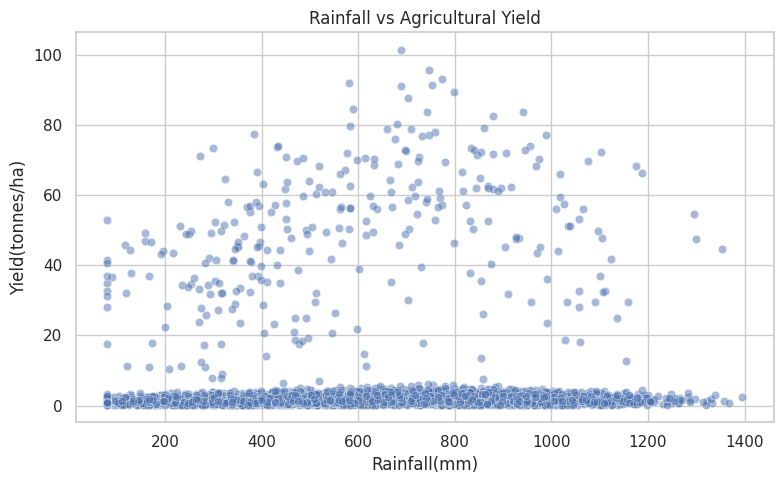

In [ ]:
#Bivariate:Rainfall vs yield
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Rainfall_mm",y="Yield_Tonnes_Ha",alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall(mm)")
plt.ylabel("Yield(tonnes/ha)")
plt.tight_layout()
plt.show()

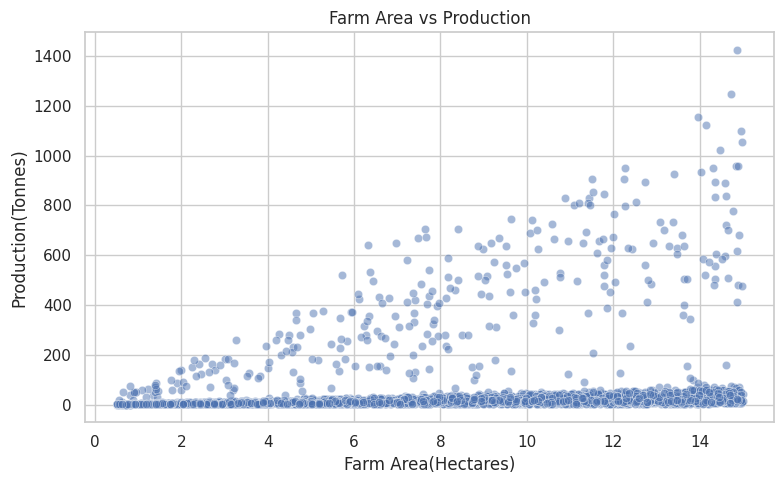

In [ ]:
 #Bivariate:farm area vs production
 plt.figure(figsize=(8,5))
 sns.scatterplot(data=df,x="Farm_Area_Hectares",y="Production_Tonnes",alpha=0.5)
 plt.title("Farm Area vs Production")
 plt.xlabel("Farm Area(Hectares)")
 plt.ylabel("Production(Tonnes)")
 plt.tight_layout()
 plt.show()

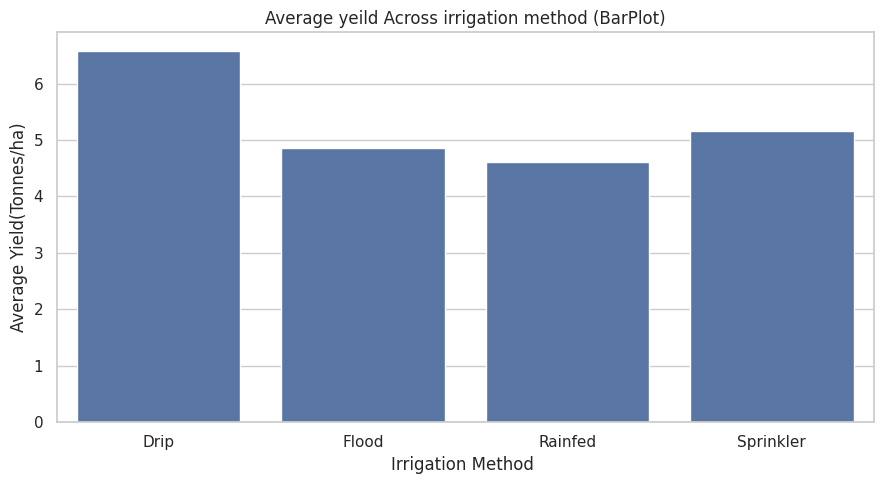

In [ ]:
plt.figure(figsize=(9,5))
sns.barplot(data=df,x="Irrigation_Method",y="Yield_Tonnes_Ha",errorbar=None)
plt.title("Average yeild Across irrigation method (BarPlot)")
plt.xlabel("Irrigation Method ")
plt.ylabel("Average Yield(Tonnes/ha)")
plt.tight_layout()
plt.show()

# 11.Multiviriate Analysis
Bivariate analysis examines relationships or differences between two variables.
Students should investigate relationships that are relevant to the seasonal agriculture problem.

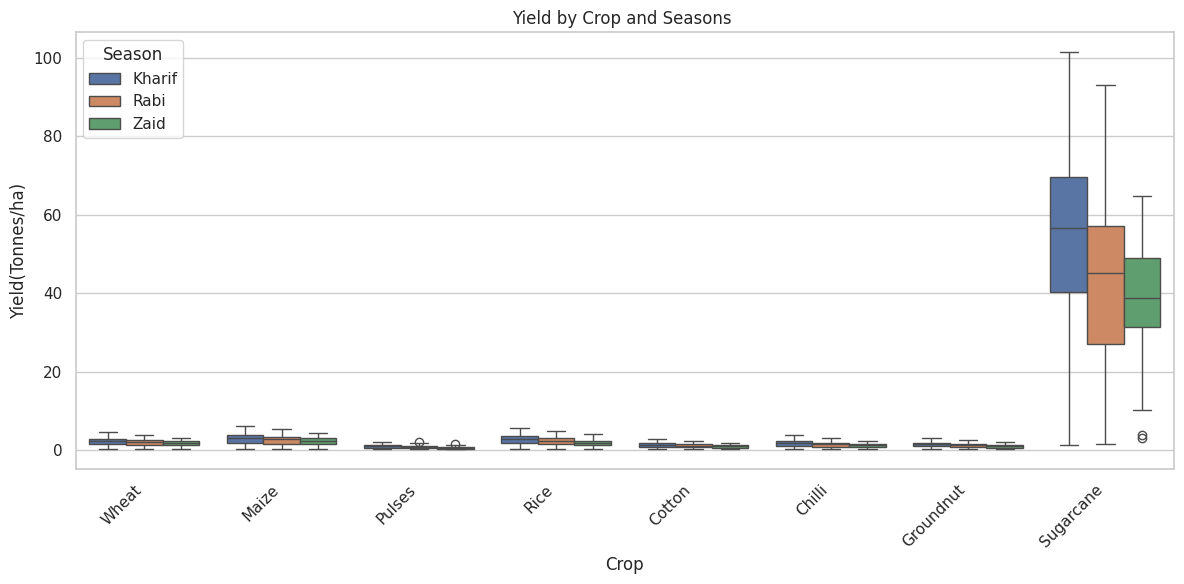

In [ ]:
#multivariate : Seasons,Crops and yeild
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="Crop",y="Yield_Tonnes_Ha",hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Seasons ")
plt.xlabel("Crop")
plt.ylabel("Yield(Tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

Multiviriate :pair plot of Key Envirnomental and Performance Metrics by season

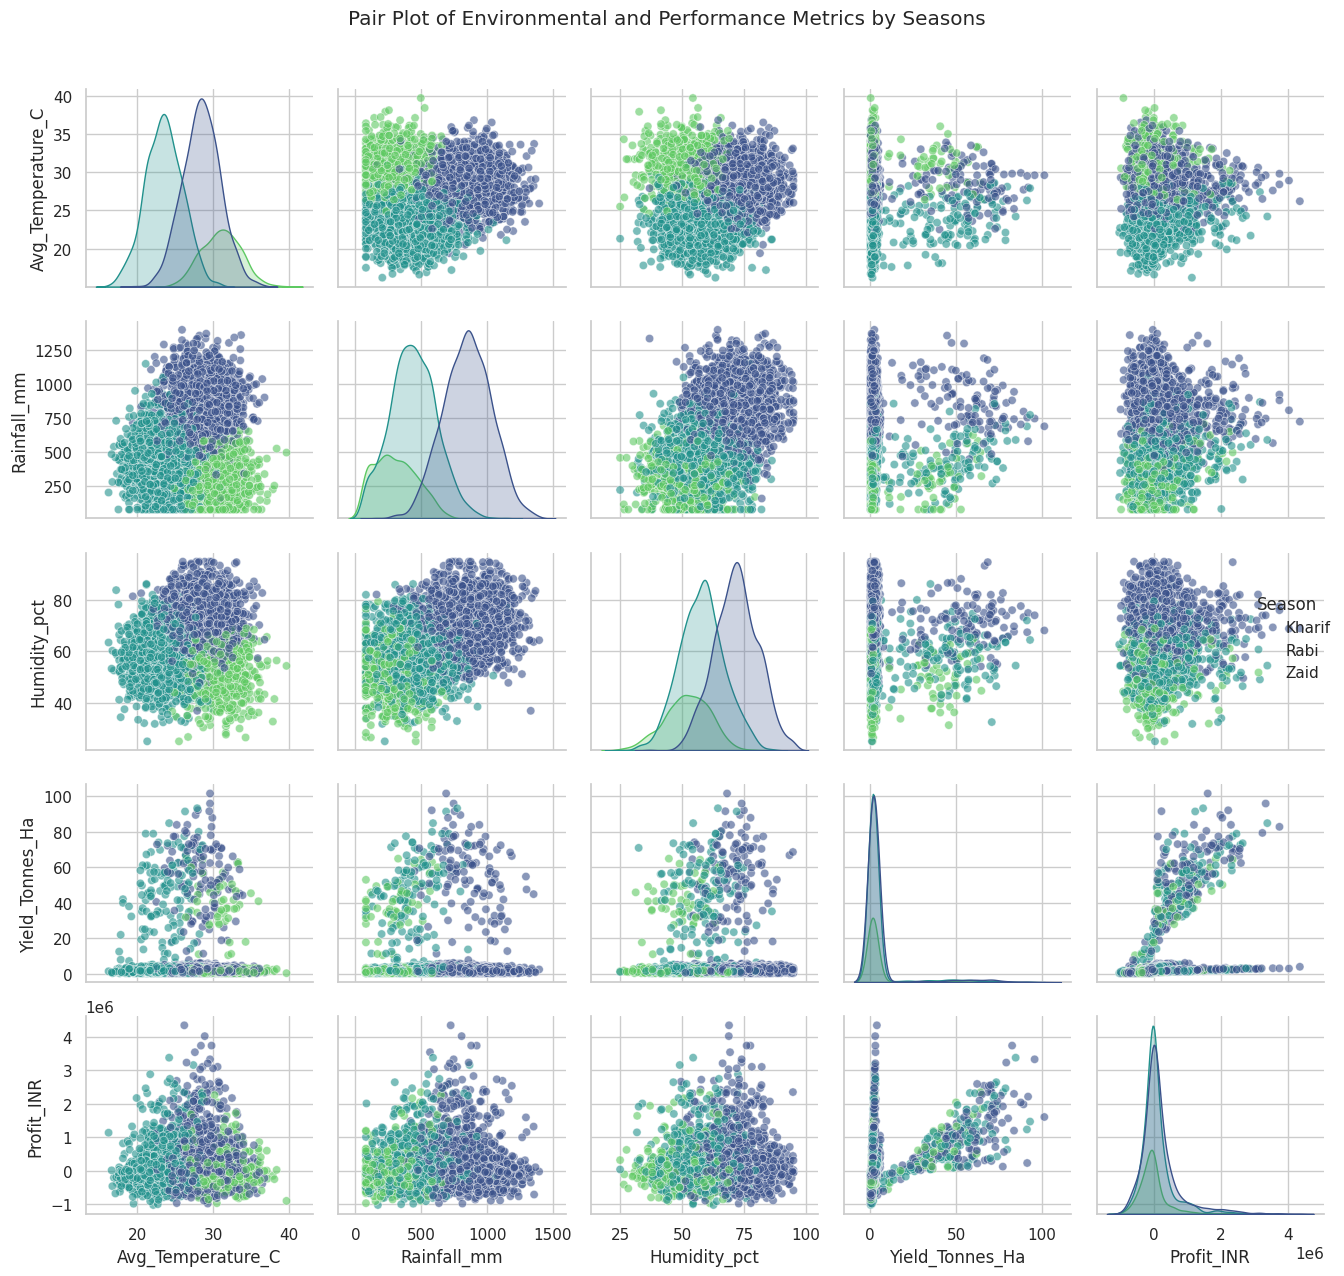

In [ ]:
selected_columns = ['Avg_Temperature_C','Rainfall_mm','Humidity_pct','Yield_Tonnes_Ha','Profit_INR','Season']
sns.pairplot(df[selected_columns],hue='Season',palette='viridis',plot_kws={'alpha':0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Seasons', y=1.02)#adjust suptitle position
plt.tight_layout()
plt.show()

In [ ]:
crop_season_summary = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().reset_index()
crop_season_summary = crop_season_summary.rename(columns={'Yield_Tonnes_Ha': 'Average_Yield'})

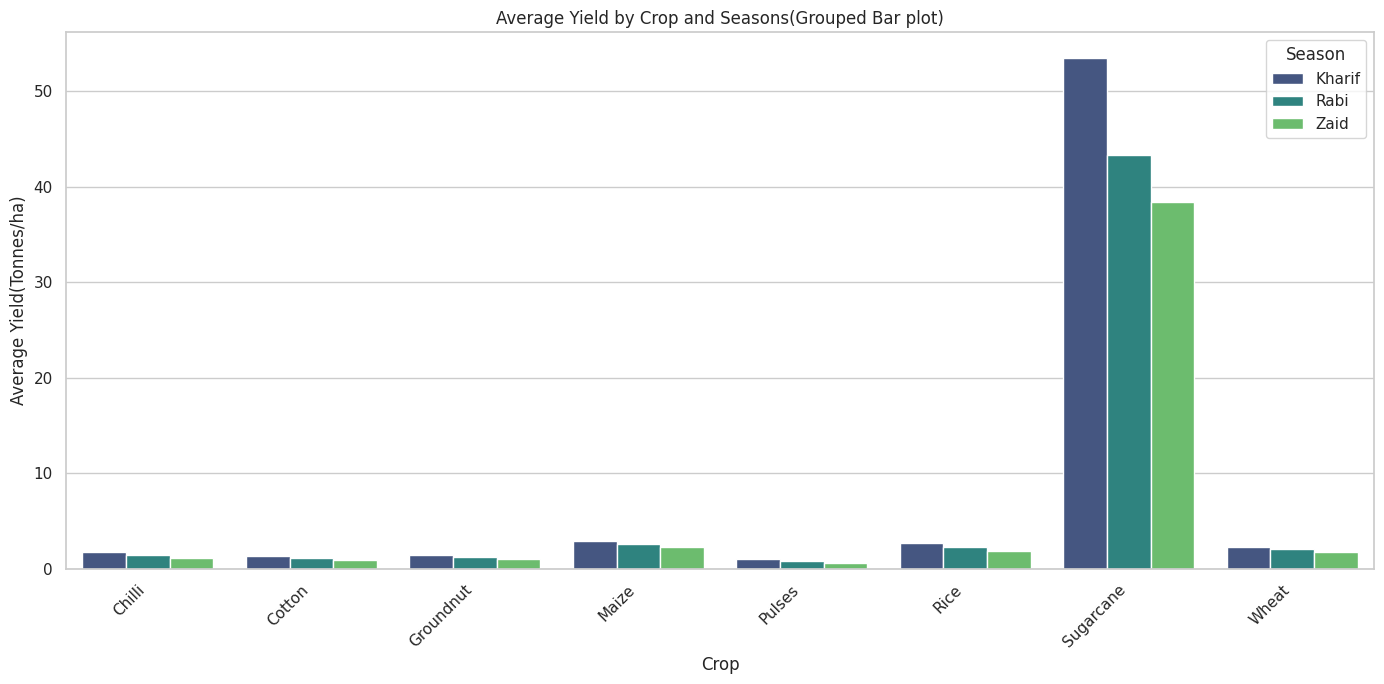

In [ ]:
plt.figure(figsize=(14,7))
sns.barplot(data=crop_season_summary.reset_index(),x="Crop",y="Average_Yield",hue="Season",palette="viridis")
plt.title("Average Yield by Crop and Seasons(Grouped Bar plot)")
plt.xlabel("Crop")
plt.ylabel("Average Yield(Tonnes/ha)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

multivariate :pair plot of the key Envoirnment and performance meterics by Seasons

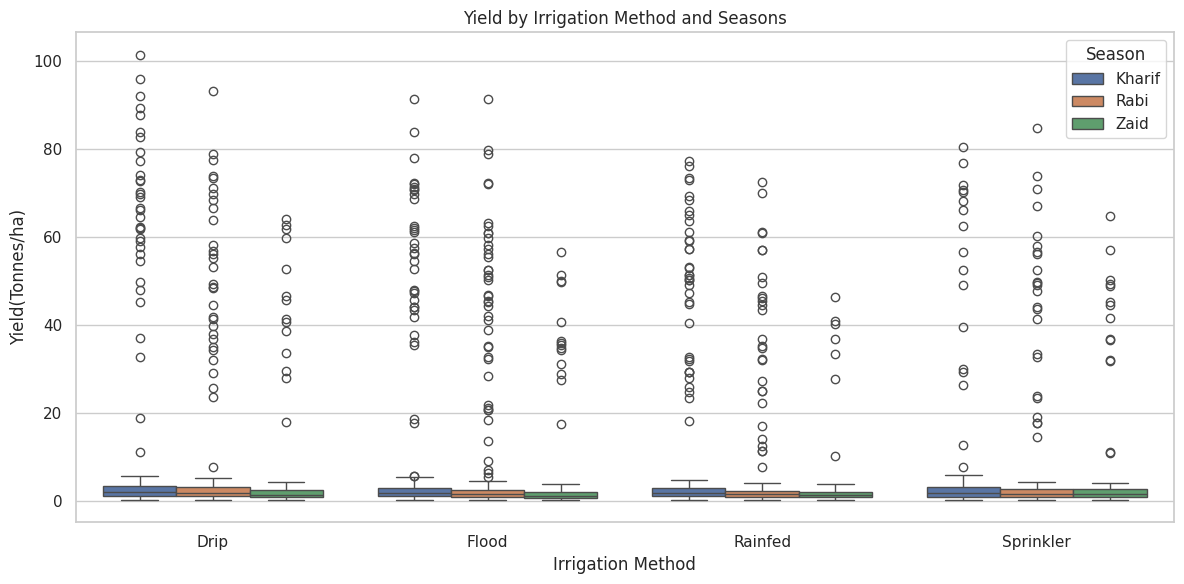

In [ ]:
#Multivariate:season,irrigation and yeild
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="Irrigation_Method",y="Yield_Tonnes_Ha",hue="Season")
plt.title("Yield by Irrigation Method and Seasons")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield(Tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


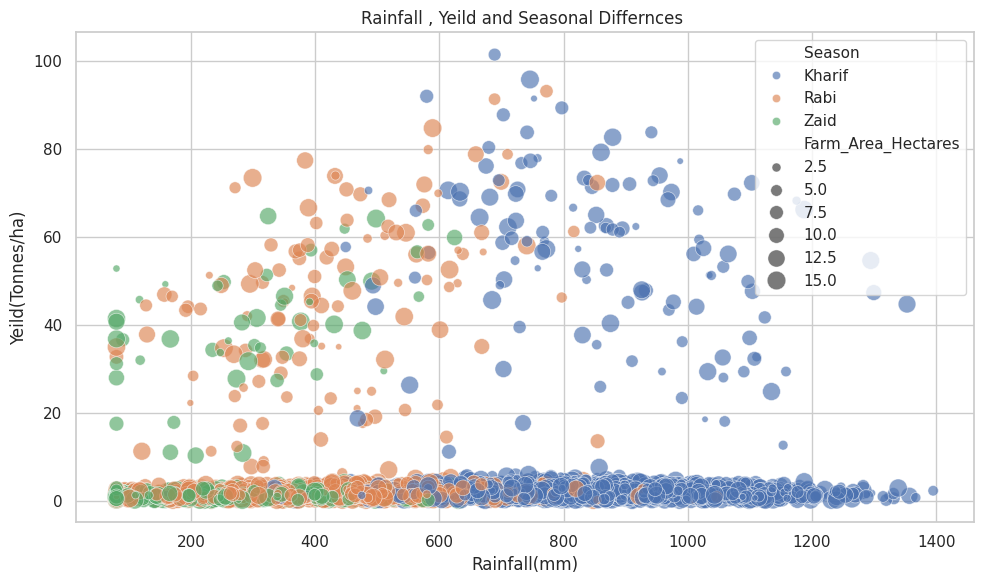

In [ ]:
# multivariate:Rainfall,yeild and Season
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Rainfall , Yeild and Seasonal Differnces ")
plt.xlabel("Rainfall(mm)")
plt.ylabel("Yeild(Tonnes/ha)")
plt.tight_layout()
plt.show()

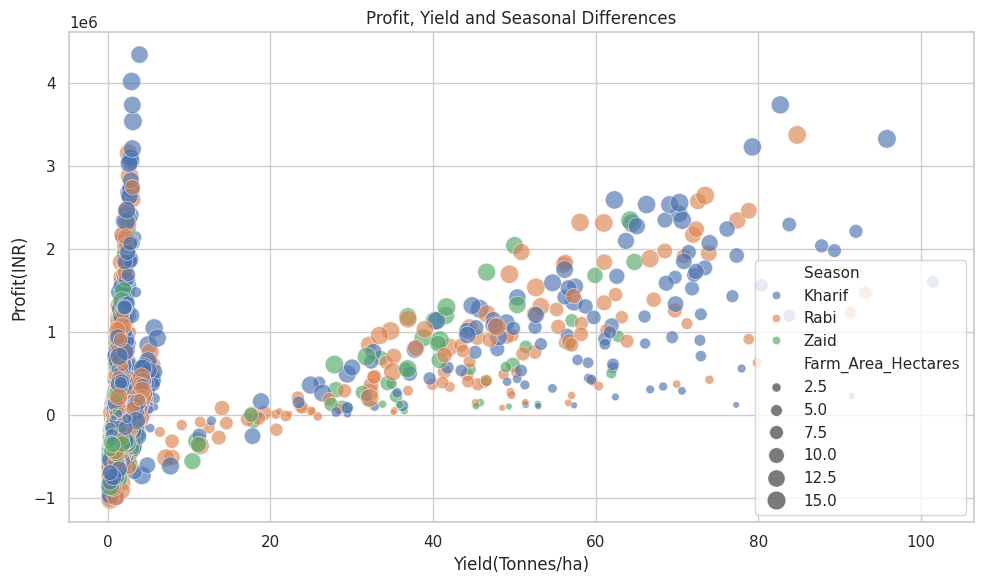

In [ ]:
#Multiviriate :profit,yeild and season
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Profit, Yield and Seasonal Differences")
plt.xlabel("Yield(Tonnes/ha)")
plt.ylabel("Profit(INR)")
plt.tight_layout()
plt.show()

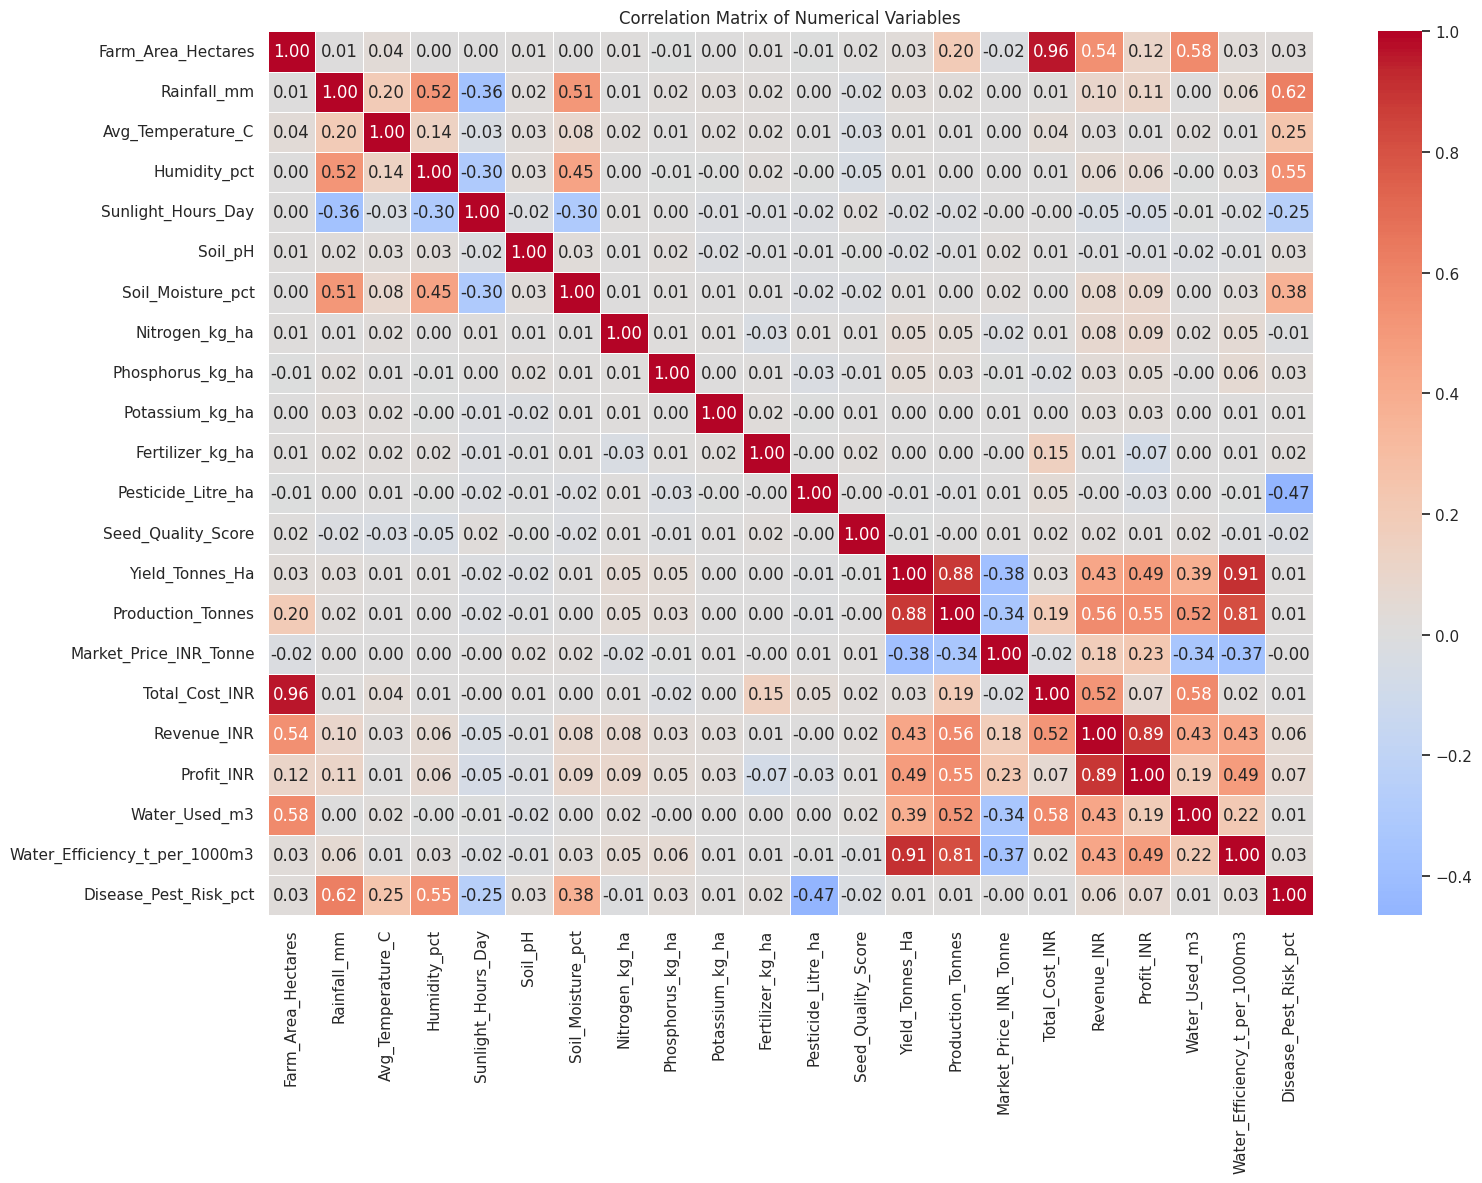

In [ ]:
#correlation heatmap for numerical variables
plt.figure(figsize=(16,12))
corr= df[numeric_columns].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center = 0,
    linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

## 12.Seasonal Comparision


In [ ]:
seasons_metrics = df.groupby("Season").agg(
    Records=("Farm_ID","count"),
    Average_Yield=("Yield_Tonnes_Ha","mean"),
    Total_production=("Production_Tonnes","sum"),
    Total_profit=("Profit_INR","sum"),
    Average_profit=("Profit_INR","mean"),
    Average_water_used=("Water_Used_m3","mean"),
).round(2)
seasons_metrics

,Records,Average_Yield,Total_production,Total_profit,Average_profit,Average_water_used
Season,,,,,,
Kharif,1779,5.63,"82,387.61",318289158,"178,914.65","6,102.20"
Rabi,1627,5.04,"67,498.88",142670768,"87,689.47","5,846.99"
Zaid,594,4.64,"23,098.35",-14734066,"-24,804.82","6,419.89"


In [ ]:
crop_season_summary =(
    df.groupby (["Season","Crop"]).agg(
        Average_yield=("Yield_Tonnes_Ha","mean"),
        Average_profit=("Profit_INR","mean"),
        Average_water_efficiency=("Water_Efficiency_t_per_1000m3","mean"),
    )
    .round(2)
    .sort_values(["Season","Average_yield"],ascending=[True,False])
)
crop_season_summary

Average_yield  Average_profit  Average_water_efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

# 13.Additional Student-Driven Analysis


### 13.1. Regional Differences: Average Profit by State

**Relevance:** Understanding which states or regions are experiencing higher or lower profits can help in identifying areas that might need specific support, policy changes, or where best practices could be shared. It highlights geographical disparities in agricultural success.

/tmp/ipykernel_2485/3673253766.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='State', y='Profit_INR', data=avg_profit_by_state, palette='viridis')


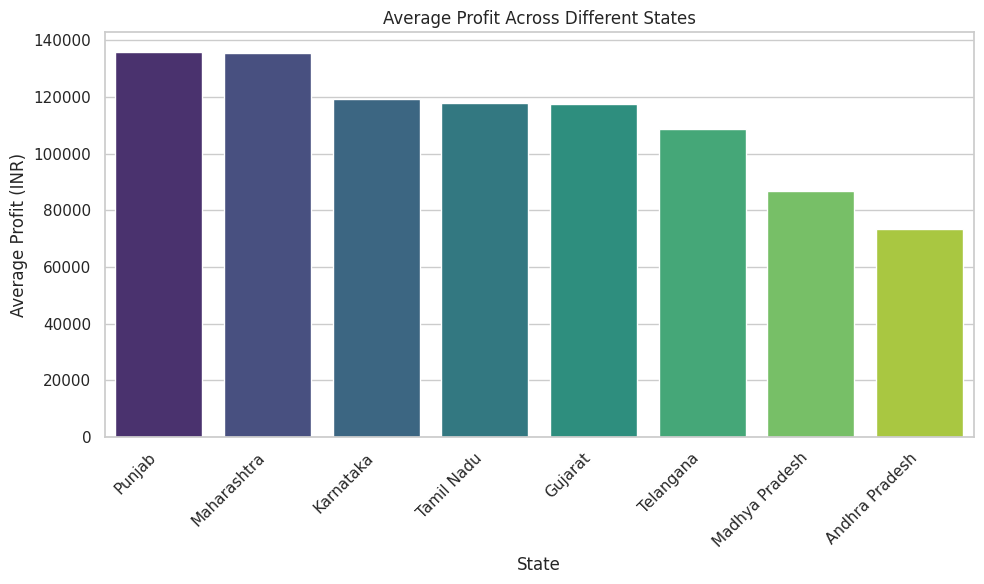

In [ ]:
avg_profit_by_state = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='State', y='Profit_INR', data=avg_profit_by_state, palette='viridis')
plt.title('Average Profit Across Different States')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 13.2. Crop-Specific Seasonal Yield Patterns

**Relevance:** This analysis is crucial for optimal crop planning. By visualizing how the yield of specific crops varies across different seasons, farmers and policymakers can make informed decisions about which crops to cultivate in which season to maximize productivity and profitability.

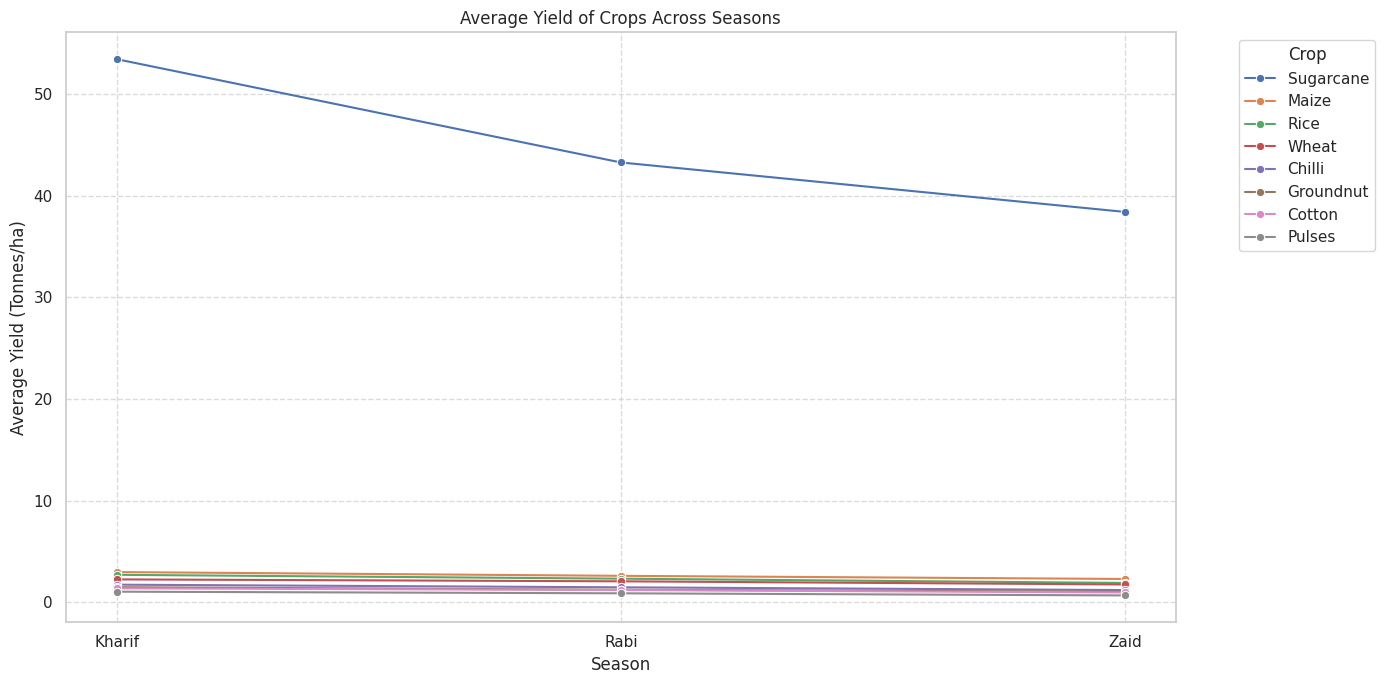

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='Season', y='Average_yield', hue='Crop', data=crop_season_summary, marker='o')
plt.title('Average Yield of Crops Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/ha)')
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 13.3. Economic Performance: Correlation of Profit with Key Variables

**Relevance:** Understanding which factors have the strongest correlation (positive or negative) with profit is vital for improving economic outcomes. This analysis helps identify drivers of profitability, allowing for targeted management strategies and resource allocation to boost farmers' income.

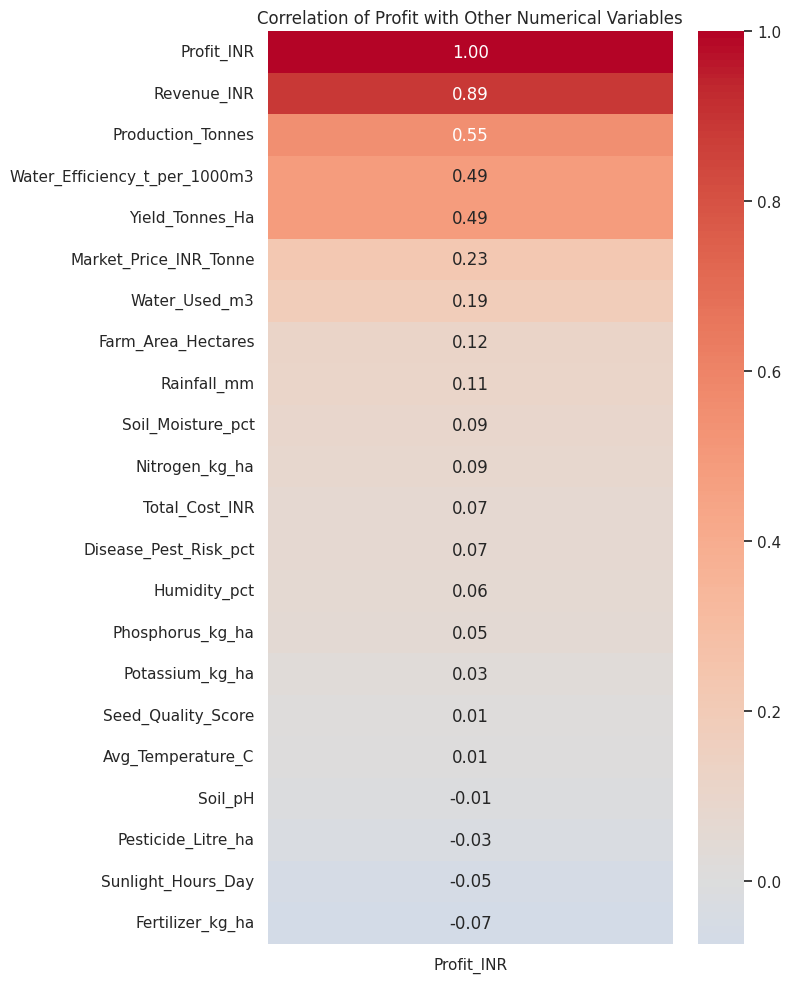

In [ ]:
profit_correlations = corr['Profit_INR'].sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(profit_correlations.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Correlation of Profit with Other Numerical Variables')
plt.tight_layout()
plt.show()

14.Key Insights

### Insight 1: Significant Seasonal Variation in Profitability

1.  **Observation**: The Kharif season consistently demonstrates the highest average profit, while the Zaid season, on average, results in financial losses for farms.
2.  **Evidence**: The `seasons_metrics` table shows an average profit of 178,914.65 INR for Kharif, 87,689.47 INR for Rabi, and -24,804.82 INR for Zaid. This is further visualized in the 'Profit Distribution Across Seasons' box plot (`lJL8H1w3VH-r` and `9MGUWFIbryzW`), where Kharif's profit distribution is notably higher than Rabi and Zaid.
3.  **Interpretation**: The Kharif season appears to be the most economically favorable period for agriculture, suggesting that the crops cultivated, environmental conditions, or market dynamics during this season are more conducive to profitability. The Zaid season presents significant financial challenges, possibly due to higher resource costs, lower yields, or adverse market conditions.
4.  **Limitation**: This observation highlights an association between season and profit, but it does not fully explain the specific underlying causal factors such as precise crop choices, detailed market demand, or the precise impact of varying environmental conditions within each season.

### Insight 2: High Variability and Outliers in Agricultural Yield

1.  **Observation**: While the majority of agricultural yields are relatively low, the dataset contains a notable number of extreme outliers, indicating exceptionally high-performing farms or specific high-yield crops.
2.  **Evidence**: The univariate box plot for 'Yield_Tonnes_Ha' (`8u4WvLXQdo3T`) clearly displays a concentrated distribution at lower yield values with many individual points extending far above the upper quartile. The `outlier_summary` table further quantifies this, showing 302 identified outliers (7.55% of the data) for 'Yield_Tonnes_Ha'.
3.  **Interpretation**: Agricultural productivity is highly diverse. The presence of significant outliers suggests that certain farming practices, specific crop varieties, or localized optimal conditions can lead to considerably higher yields than the average. These instances could represent best practices or unique circumstances worth further investigation.
4.  **Limitation**: Identifying outliers doesn't inherently imply data errors. These high yields could be legitimate successes. Further analysis is required to understand the specific characteristics (e.g., crop type, location, inputs) that contribute to these exceptional yields, rather than assuming they are anomalies to be discarded.

### Insight 3: Strong Positive Correlation Between Revenue, Production, and Profit

1.  **Observation**: Profit is very strongly positively correlated with revenue and moderately positively correlated with production volume.
2.  **Evidence**: The 'Correlation Matrix of Numerical Variables' heatmap (`c5xeWpwrM1EO`) shows a correlation coefficient of 0.89 between 'Profit_INR' and 'Revenue_INR', and 0.55 between 'Profit_INR' and 'Production_Tonnes'. The 'Correlation of Profit with Other Numerical Variables' heatmap (`cd328a3f`) also lists 'Revenue_INR' and 'Production_Tonnes' as the top two variables most positively correlated with profit.
3.  **Interpretation**: As expected, higher revenue directly translates to increased profits, highlighting the importance of market performance and pricing. Additionally, greater production volumes contribute significantly to higher profits, suggesting that scaling operations and maximizing output are key drivers of financial success for farms in this dataset.
4.  **Limitation**: While these are strong associations, they do not imply a simple causal chain where increasing production alone guarantees higher profit. Factors such as input costs, market price stability, and sales efficiency are also crucial in converting production and revenue into actual profit. For instance, overproduction could depress market prices.

### Insight 4: Notable Regional Disparities in Average Agricultural Profit

1.  **Observation**: There are distinct differences in average agricultural profit across various states, with Punjab and Maharashtra exhibiting significantly higher average profits compared to states like Andhra Pradesh and Madhya Pradesh.
2.  **Evidence**: The 'Average Profit Across Different States' bar plot (`458c91b9`) visually confirms this, with Punjab showing the highest average profit (136,025.64 INR) and Andhra Pradesh showing the lowest (73,453.53 INR), as detailed in the `avg_profit_by_state` DataFrame.
3.  **Interpretation**: Geographic location plays a substantial role in agricultural economic performance. This disparity could be attributed to variations in local climate, soil fertility, prevailing crop types, access to markets, governmental agricultural policies, or technological adoption rates within these states.
4.  **Limitation**: This analysis reveals a strong association between the state and profitability but does not isolate the specific state-level factors that are directly causing these differences. Further investigation into local conditions, predominant crops, and agricultural practices within each state would be necessary to identify root causes.

### Insight 5: Crop-Specific Yield Patterns Vary Drastically by Season

1.  **Observation**: The average yield performance of individual crops varies considerably across different seasons (Kharif, Rabi, Zaid), with Sugarcane consistently showing exceptionally high yields in all seasons compared to other crops.
2.  **Evidence**: The `crop_season_summary` table clearly illustrates this, showing Sugarcane yields of 53.46 Tonnes/Ha in Kharif, 43.29 in Rabi, and 38.42 in Zaid. In contrast, crops like Pulses maintain consistently lower yields across all seasons (e.g., 1.04 in Kharif, 0.88 in Rabi, 0.67 in Zaid). This is also visible in the 'Average Yield of Crops Across Seasons' line plot (`e918c1b4`) and the 'Average Yield by Crop and Seasons' grouped bar plot (`sXjz30heAFqo`).
3.  **Interpretation**: Optimal crop selection based on seasonal suitability is a critical factor for maximizing agricultural output. Matching crop requirements (e.g., temperature, water) with seasonal environmental conditions can lead to significantly improved yields. Sugarcane demonstrates a robust adaptability and high productivity across the various seasons.
4.  **Limitation**: While the patterns are clear, this analysis doesn't detail the specific environmental thresholds or optimal conditions for each crop in each season. External factors such as pest resistance, specific market demands for certain crops, or cultivation practices tailored to each season are not explicitly covered.

### Insight 6: Rainfall's Influence on Yield is Season-Dependent and Complex

1.  **Observation**: There is a general positive association between rainfall and yield, but this relationship is not straightforward and is significantly modulated by the season. The Kharif season, characterized by higher rainfall, exhibits a wide range of yields, suggesting varying effectiveness of rainfall.
2.  **Evidence**: The 'Rainfall vs Agricultural Yield' scatterplot (`VLv7sLYivY61`) shows a diffuse but upward trend in yield with increasing rainfall. The 'Rainfall, Yield and Seasonal Differences' scatterplot (`eroJDmEuF_LC`) further elaborates, showing Kharif data points predominantly in higher rainfall regions but with highly variable yields, while Rabi and Zaid show lower rainfall with more constrained yield ranges.
3.  **Interpretation**: Adequate rainfall is generally beneficial for crop growth and yield. However, the timing and intensity of rainfall within a season are crucial. The variability in Kharif yields despite high rainfall could indicate issues with excessive rain, poor drainage, or other factors that diminish the positive impact of precipitation. Managing water effectively (e.g., drainage) during high rainfall periods might be as important as ensuring supply during low rainfall.
4.  **Limitation**: This analysis establishes a correlation rather than direct causation. It doesn't differentiate between beneficial and detrimental rainfall patterns (e.g., flooding vs. optimal irrigation) or account for crop-specific water requirements. The overall effectiveness of rainfall on yield is influenced by many other variables not isolated here.

### Insight 7: Irrigation Method Significantly Impacts Average Yield

1.  **Observation**: Farms utilizing Drip and Flood irrigation methods tend to achieve higher average yields compared to those relying on Rainfed or Sprinkler irrigation methods.
2.  **Evidence**: The 'Average yield Across irrigation method (BarPlot)' (`fuquFYCr20wf`) clearly shows that Drip and Flood irrigation methods correspond to a higher average 'Yield_Tonnes_Ha'. The 'Yield by Irrigation Method and Seasons' boxplot (`Wfo6VWGAFH9K`) reinforces this pattern, demonstrating that these methods often have higher median yields across various seasons.
3.  **Interpretation**: The choice of irrigation method is a critical operational factor influencing agricultural productivity. Drip and Flood irrigation methods appear to be more effective in delivering water efficiently or in suitable quantities to support higher crop yields under the observed conditions in the dataset.
4.  **Limitation**: This insight shows an association. The observed differences could be confounded by other factors, such as the specific crops grown with each irrigation method, the size of the farms, the soil types, or the environmental conditions where these methods are predominantly used. It does not imply that simply adopting Drip or Flood irrigation will universally lead to higher yields without considering these contextual factors.

### Insight 8: Moderate Positive Correlation between Market Price and Profit

1.  **Observation**: There is a moderate positive correlation between the market price of agricultural produce per tonne and the overall farm profit.
2.  **Evidence**: The correlation heatmap (`c5xeWpwrM1EO`) indicates a correlation coefficient of 0.23 between 'Market_Price_INR_Tonne' and 'Profit_INR'. The `profit_correlations` series (`cd328a3f`) also lists market price as a positively correlated factor with profit.
3.  **Interpretation**: Higher selling prices for crops generally lead to increased farm profitability. This is a fundamental economic principle, as a better market price directly boosts revenue, contributing to higher profits, assuming production costs are managed.
4.  **Limitation**: While positive, the correlation coefficient of 0.23 is only moderate. This suggests that while market price is a contributing factor, it is not the sole determinant of profit. Other variables such as total production volume, operational costs, and yield efficiency also play significant roles in the final profitability of a farm.

# 15.1 Recommendation 1: Optimize Seasonal Agricultural Planning

1.  **Based on Insight 1 (Significant Seasonal Variation in Profitability)**: Farmers and agricultural planners should strategically prioritize resource allocation, crop selection, and investment towards the Kharif season to maximize overall agricultural profitability.
2.  **Specific Action**: For the Zaid season, given its consistent financial losses, a thorough review of cost structures, market demand, and potential alternative, more resilient crop varieties or farming practices is recommended to mitigate these losses.
3.  **Limitations Acknowledged**: This recommendation highlights observed seasonal profitability differences but does not account for the specific factors (e.g., precise crop demand, specific environmental stressors) within each season that drive these profit differences, which would require deeper localized analysis.

### Recommendation 2: Identify and Replicate High-Yield Best Practices

1.  **Based on Insight 2 (High Variability and Outliers in Agricultural Yield)**: Conduct in-depth case studies on farms that consistently achieve exceptionally high yields to identify the specific best practices, crop varieties, and localized environmental conditions contributing to their success.
2.  **Specific Action**: Disseminate these identified best practices and knowledge (e.g., through farmer training programs, agricultural extension services) to other farmers to improve overall yield performance across the region.
3.  **Limitations Acknowledged**: While these outliers represent high performance, the exceptional results may be due to unique, non-replicable circumstances (e.g., very specific microclimates, niche markets) not fully captured in the dataset. Further investigation is needed to ensure scalability and transferability of these practices.

### Recommendation 3: Implement Holistic Strategies for Profit Optimization

1.  **Based on Insight 3 (Strong Positive Correlation Between Revenue, Production, and Profit)**: Implement strategies that simultaneously focus on optimizing both production volume and the market value of produce to drive profitability.
2.  **Specific Action**: Encourage the adoption of efficient farming techniques to increase yield per hectare. Additionally, farmers should explore value-added processing, direct marketing channels, or collective bargaining to enhance revenue from their produce. Effective cost management is crucial to ensure that increased revenue translates directly into higher profits.
3.  **Limitations Acknowledged**: Increasing production does not automatically guarantee higher profits if it leads to market saturation or if the increases in production costs outweigh the revenue gains. A balanced approach considering market dynamics and cost control is essential.

### Recommendation 4: Regional Policy and Knowledge Transfer

1.  **Based on Insight 4 (Notable Regional Disparities in Average Agricultural Profit)**: Policymakers and agricultural support organizations should investigate the specific success factors and agricultural ecosystems in high-profit states (e.g., Punjab, Maharashtra).
2.  **Specific Action**: Assess the feasibility of adapting and implementing similar beneficial practices, supportive policies, or infrastructure improvements in lower-profit states (e.g., Andhra Pradesh, Madhya Pradesh) to help reduce regional disparities in agricultural economic performance.
3.  **Limitations Acknowledged**: Direct transfer of practices or policies may not be universally suitable due to inherent differences in local environmental conditions, predominant soil types, prevalent crop types, cultural farming practices, and existing market structures across states.

### Recommendation 5: Promote Crop Diversification and Seasonal Suitability

1.  **Based on Insight 5 (Crop-Specific Yield Patterns Vary Drastically by Season)**: Promote educated crop diversification and seasonal suitability planning among farmers.
2.  **Specific Action**: Encourage farmers to select crops that are demonstrably best suited to the specific environmental conditions and market demands of each season, based on data. While Sugarcane shows robust performance, other crops need careful seasonal consideration to maximize yield and profitability.
3.  **Limitations Acknowledged**: This analysis primarily focuses on yield. It does not explicitly account for market demand fluctuations, pricing volatility, or specific input costs associated with different crops and seasons, which are critical components of overall profitability and farmer decision-making.

### Recommendation 6: Enhance Water Management Strategies

1.  **Based on Insight 6 (Rainfall's Influence on Yield is Season-Dependent and Complex)**: Implement improved, season-specific water management practices.
2.  **Specific Action**: Especially in the Kharif season, where high rainfall is observed but yields vary, focus should be on both ensuring adequate water supply (if needed) and, critically, on efficient drainage systems to prevent yield losses from excessive rainfall. Investment in local weather monitoring and precise forecasting can inform timely planting and water management decisions.
3.  **Limitations Acknowledged**: This recommendation assumes that water management improvements (e.g., drainage infrastructure) are economically viable and technically feasible for all farmers, which may vary significantly based on farm size, terrain, and financial resources.

### Recommendation 7: Invest in Efficient Irrigation Technologies

1.  **Based on Insight 7 (Irrigation Method Significantly Impacts Average Yield)**: Encourage and support the adoption of Drip and Flood irrigation methods.
2.  **Specific Action**: Given their observed association with higher average yields, provide training, subsidies, or financial incentives for farmers to transition to these more effective irrigation techniques where feasible and appropriate. This will help optimize water usage and boost productivity.
3.  **Limitations Acknowledged**: This recommendation highlights an association and does not fully consider the initial capital investment, ongoing maintenance costs, regional water availability constraints, or suitability for all crop types and terrains, which can be significant barriers to widespread adoption.

### Recommendation 8: Strengthen Market Access and Information for Farmers

1.  **Based on Insight 8 (Moderate Positive Correlation between Market Price and Profit)**: Empower farmers with better market information and enhance their negotiation capabilities.
2.  **Specific Action**: Support initiatives that provide farmers with real-time market price data and connect them directly to buyers (e.g., through digital platforms, farmer cooperatives) to help them achieve optimal selling prices for their produce. Promoting value-added products can also enhance market price realization and reduce dependency on intermediaries.
3.  **Limitations Acknowledged**: While market price is important, a moderate correlation suggests it's not the sole driver of profit. Focusing solely on market price without simultaneously controlling operational costs, improving yield efficiency, and managing supply chain risks may not guarantee sustainable increases in profitability.

16.Conclusion

## 16. Conclusion

### Summary of Seasonal Agricultural Performance Analysis

This analysis of the agricultural dataset aimed to investigate seasonal differences in agricultural performance, identify meaningful patterns, and provide data-driven insights and recommendations.

#### What the Dataset Revealed About Seasonal Agricultural Performance:

*   **Significant Seasonal Profitability Differences**: The **Kharif** season emerged as the most profitable, followed by **Rabi**, while the **Zaid** season consistently showed financial losses. This highlights a critical seasonality in economic viability.
*   **Crop-Specific Seasonal Suitability**: Different crops exhibit varying yield performances across seasons. Sugarcane notably maintains high yields across all seasons, while others like Pulses show consistently lower yields.
*   **Variability in Environmental Factors**: Rainfall, temperature, and humidity show distinct seasonal patterns, influencing yields in complex, non-linear ways.

#### Most Important Patterns Discovered:

1.  **Kharif Season Dominance**: The Kharif season generally offers the best conditions for overall agricultural profitability and often higher yields for many crops, despite potentially high rainfall variability.
2.  **Zaid Season Challenges**: The Zaid season presents the greatest financial challenges, suggesting that current farming practices or crop selections for this period are often unprofitable.
3.  **High Yield Variability and Outliers**: The presence of numerous high-yield outliers indicates that certain combinations of practices, crops, or conditions can lead to exceptional productivity, far exceeding the average.
4.  **Strong Economic Drivers**: Profit is heavily driven by Revenue and Production volume, while market price plays a moderate, but still significant, role.
5.  **Regional Disparities**: Agricultural profitability is not uniform across states, with some states consistently outperforming others, likely due to a confluence of local factors.
6.  **Irrigation Method Impact**: Drip and Flood irrigation methods are strongly associated with higher average yields, suggesting their effectiveness in water delivery.

#### Most Useful Analytical Findings:

*   **Quantified Seasonal Profitability**: The specific average profit figures for each season (`Kharif: 178,914.65 INR`, `Rabi: 87,689.47 INR`, `Zaid: -24,804.82 INR`) provide clear benchmarks for strategic planning.
*   **Correlation Strengths**: Strong correlations between Profit and Revenue (0.89) and Production (0.55) underscore the importance of maximizing output and market realization. The moderate correlation with Market Price (0.23) indicates that price alone isn't the sole determinant of profit.
*   **Outlier Identification**: The identification of high-yield outliers (7.55% of data) pinpoints specific instances of exceptional performance that warrant further investigation to uncover best practices.
*   **State-Level Performance Ranking**: The ranking of states by average profit (e.g., Punjab highest, Andhra Pradesh lowest) provides a clear geographical perspective on performance disparities.

#### Important Limitations of the Analysis:

*   **Associative vs. Causal**: Many findings highlight strong associations (e.g., season and profit, irrigation method and yield) but do not definitively establish direct causation. Confounding variables are always a possibility.
*   **Lack of Granular Cost/Revenue Data**: The dataset did not provide highly detailed breakdowns of cost components or market demand fluctuations, which would offer deeper insights into profitability drivers and limitations.
*   **Generalizability**: The findings are based on a specific dataset and may not be universally generalizable to all agricultural contexts without further validation.
*   **Outlier Investigation**: While outliers were identified, the analysis did not delve into the specific unique characteristics of these high-performing farms or crops.

#### How the Analysis Could Support Future Investigation or Decision-Making:

*   **Strategic Seasonal Planning**: Farmers and policymakers can use the seasonal profitability data to make informed decisions on crop selection, resource allocation, and investment, prioritizing the Kharif season and rethinking the Zaid season.
*   **Best Practice Identification**: The presence of high-yield outliers provides a strong impetus for future research into specific successful farming techniques, crop varieties, or environmental adaptations that can be replicated.
*   **Targeted Interventions**: States with consistently lower profits can be targeted for specific support, policy adjustments, or knowledge transfer programs based on practices from higher-performing states.
*   **Technology Adoption**: The clear impact of irrigation methods suggests promoting Drip and Flood systems, accompanied by training and potential subsidies, to boost yields.
*   **Market Optimization**: Understanding the moderate correlation of market price with profit encourages initiatives for better market information, direct selling channels, and value-added processing to empower farmers.

This analysis serves as a foundational step, providing critical insights that can guide more detailed studies and data-driven agricultural development initiatives.